In [1]:
# The "!" at the start lets us run Linux/shell commands inside a notebook cell.
# This is super useful in cloud environments.

# Command 1: Check CPU details (which processor Google gave us)
# 'cat /proc/cpuinfo' prints CPU info; 'grep "model name"' filters only the name;
# 'head -1' shows just the first line (since there are multiple cores)
!cat /proc/cpuinfo | grep "model name" | head -1

# Command 2: Check how much RAM (memory) this machine has
# '-h' means "human-readable" (shows GB instead of raw bytes)
!free -h

# Command 3: Check how much disk space we have
# '-h' again for human-readable output
!df -h / | head -2

model name	: AMD EPYC 7B12
               total        used        free      shared  buff/cache   available
Mem:            12Gi       578Mi       9.1Gi       1.0Mi       3.0Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  20% /


In [2]:
# 'nvidia-smi' is a command from NVIDIA that shows GPU information.
# If you see a table with "Tesla T4" or similar — congrats, you have a free GPU!
# If you see "command not found", go back and enable GPU in Runtime settings.

!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
# Import the 'drive' module from Google Colab's built-in library.
from google.colab import drive

# This line tells Colab to mount your Google Drive at the path '/content/drive'.
# When you run this, a pop-up will ask you to:
#   1. Click a link to authorize Colab.
#   2. Sign in with your Google account.
#   3. Copy a code and paste it back here.
# After that, your Drive is accessible like any regular folder!
drive.mount('/content/drive')

# Let's verify by listing files in the root of our Drive.
# The '!' runs this as a shell command (list directory contents).
!ls /content/drive/MyDrive/ | head -10

MessageError: Error: credential propagation was unsuccessful

In [4]:
import pandas as pd

df_california = pd.read_csv('/content/sample_data/california_housing_train.csv')
display(df_california.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [5]:
# 'pip' is Python's package installer.
# The '-q' flag means "quiet" — don't print every download step (keeps output clean).
# In Colab, '!pip install' is the standard way to install libraries.

!pip install -q yellowbrick

# After installing, let's import it to confirm it works:
import yellowbrick
print(f"✅ yellowbrick version {yellowbrick.__version__} installed successfully!")

✅ yellowbrick version 1.5 installed successfully!


In [6]:
# Import the libraries we need.
# - pandas: for data tables (like Excel in Python)
# - sklearn.datasets: has several built-in datasets for learning

import pandas as pd
from sklearn.datasets import load_iris

# Load the iris dataset into a variable.
iris = load_iris()

# Convert it into a pandas DataFrame so it looks nice and is easy to work with.
# 'iris.data' = the measurements (features)
# 'iris.feature_names' = column names like 'sepal length (cm)'
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add a 'species' column.
# 'iris.target' is numbers (0, 1, 2); 'iris.target_names' maps them to flower names.
df['species'] = [iris.target_names[i] for i in iris.target]

# Show the first 5 rows to see what the data looks like.
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
# Import the libraries we need.
# - pandas: for data tables (like Excel in Python)
# - sklearn.datasets: has several built-in datasets for learning

import pandas as pd
from sklearn.datasets import load_iris

# Load the iris dataset into a variable.
iris = load_iris()

# Convert it into a pandas DataFrame so it looks nice and is easy to work with.
# 'iris.data' = the measurements (features)
# 'iris.feature_names' = column names like 'sepal length (cm)'
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add a 'species' column.
# 'iris.target' is numbers (0, 1, 2); 'iris.target_names' maps them to flower names.
df['species'] = [iris.target_names[i] for i in iris.target]

# Show the first 5 rows to see what the data looks like.
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


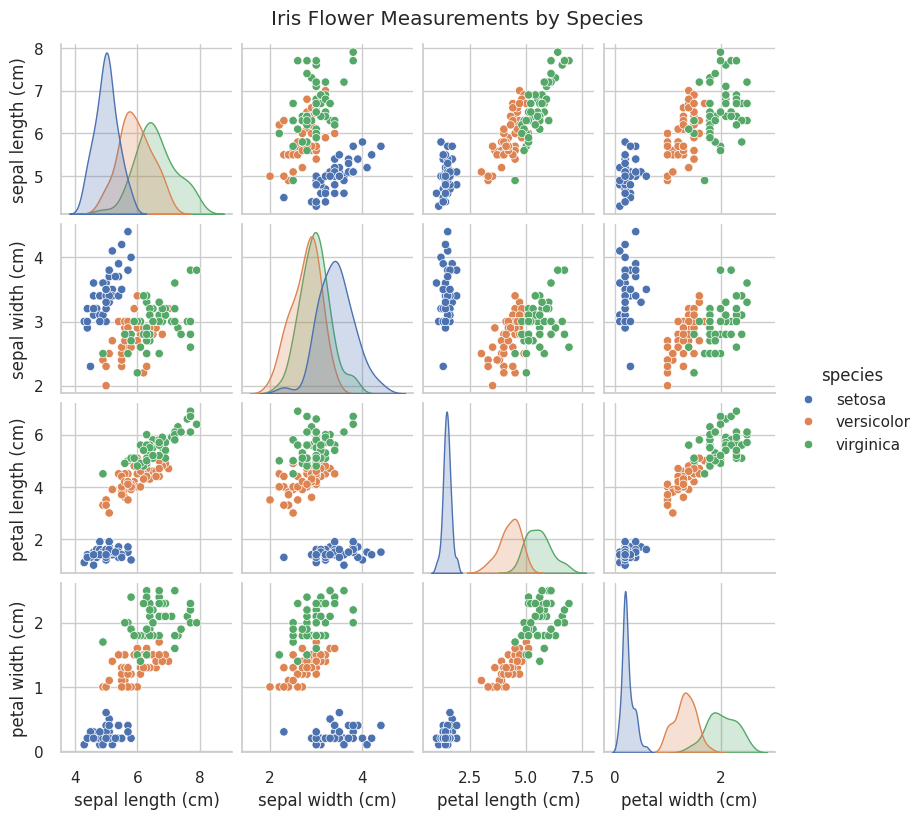

In [8]:
# Import plotting libraries.
# - matplotlib.pyplot: the core plotting library in Python
# - seaborn: prettier, statistics-focused plots built on top of matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme.
sns.set_theme(style="whitegrid")

# Create a pairplot — shows how every feature relates to every other feature,
# colored by species. Great way to see if the classes are separable.
# 'hue="species"' means color each dot by the species column.
sns.pairplot(df, hue="species", height=2)

# Add a title above the whole figure.
plt.suptitle("Iris Flower Measurements by Species", y=1.02)

# Display the plot.
plt.show()

In [9]:
# Import the tools we need from scikit-learn.
# - train_test_split: splits data into training and testing sets
# - RandomForestClassifier: the ML model we'll use (it's like many decision trees combined)
# - accuracy_score, classification_report: to measure how good our model is

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 7a: Separate features (X) from the target label (y).
# X = the measurements; y = the species we want to predict.
X = df[iris.feature_names]   # all 4 measurement columns
y = df['species']             # the species column

# Step 7b: Split the data — 80% for training, 20% for testing.
# 'random_state=42' makes the split reproducible (same split every time we run).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% of data kept for testing
    random_state=42,     # "seed" for randomness, so results are repeatable
    stratify=y           # keep the same class proportions in train and test
)

print(f"Training set size: {len(X_train)} flowers")
print(f"Testing set size:  {len(X_test)} flowers")

Training set size: 120 flowers
Testing set size:  30 flowers


In [10]:
# Step 7c: Create the model.
# n_estimators=100 means "build 100 decision trees and let them vote".
# random_state=42 again for reproducibility.
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 7d: Train (fit) the model on our training data.
# This is where the ML magic happens — it learns patterns from X_train to predict y_train.
model.fit(X_train, y_train)

print("✅ Model training complete!")

✅ Model training complete!


In [11]:
# Step 7e: Use the trained model to predict on the test set (flowers it has never seen).
y_pred = model.predict(X_test)

# Step 7f: Measure accuracy — what fraction of predictions were correct.
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%")

# Step 7g: Show a detailed breakdown per species.
# 'precision' = of the ones we said were X, how many really were X
# 'recall' = of all the real X, how many did we catch
# 'f1-score' = balance of the two above
print("\nDetailed Performance:")
print(classification_report(y_test, y_pred))

🎯 Model Accuracy: 90.00%

Detailed Performance:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [12]:
# Import joblib — a library that efficiently saves Python objects to disk.
import joblib
import os

# Decide where to save the model.
# We'll put it in our Drive, inside a folder called 'DS_Lab_Week7'.
save_folder = '/content/drive/MyDrive/DS_Lab_Week7'

# Create the folder if it doesn't already exist.
# 'exist_ok=True' means: don't raise an error if the folder is already there.
os.makedirs(save_folder, exist_ok=True)

# Full path for the saved model file.
# '.pkl' is the standard extension for pickled (saved) Python objects.
model_path = os.path.join(save_folder, 'iris_rf_model.pkl')

# Save the model!
joblib.dump(model, model_path)

print(f"✅ Model saved successfully to: {model_path}")

# Verify the file is there by listing the folder.
!ls -lh "{save_folder}"

✅ Model saved successfully to: /content/drive/MyDrive/DS_Lab_Week7/iris_rf_model.pkl
total 168K
-rw-r--r-- 1 root root 165K Apr 21 12:26 iris_rf_model.pkl


In [13]:
# Load the saved model back from Drive.
loaded_model = joblib.load(model_path)
print("✅ Model loaded from Drive!")

# Make up a new flower's measurements.
# Order must match training: sepal length, sepal width, petal length, petal width (all in cm).
new_flower = [[5.1, 3.5, 1.4, 0.2]]   # double brackets because the model expects a 2D input

# Predict which species this flower is.
prediction = loaded_model.predict(new_flower)

# Also get the probability for each species (how confident the model is).
probabilities = loaded_model.predict_proba(new_flower)

print(f"\n🌸 New flower measurements: {new_flower[0]}")
print(f"🎯 Predicted species: {prediction[0]}")
print(f"\nConfidence for each species:")
for species, prob in zip(loaded_model.classes_, probabilities[0]):
    print(f"   {species:15s}: {prob * 100:.2f}%")

✅ Model loaded from Drive!

🌸 New flower measurements: [5.1, 3.5, 1.4, 0.2]
🎯 Predicted species: setosa

Confidence for each species:
   setosa         : 100.00%
   versicolor     : 0.00%
   virginica      : 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
